# Nonlinear PDE Dataset Generation

This notebook creates matched nonlinear PDE datasets with the dataset-oriented flow as the [linear notebook](linearPDE_data_gen.ipynb).

Supported nonlinear PDEs in this codebase:
- `allen_cahn`
- `burgers`
- `cahn_hilliard`
- `fisher`
- `ginzburg_landau`
- `korteweg_de_vries`
- `kuramoto_sivashinsky`

Default workflow:
- generate a few matched `zero` and `random` trajectories
- inspect shapes, plots, and diversity
- generate a large zero/random dataset and export it

Optional workflow:
- add `ctrl` trajectories with a PPO controller only when you explicitly provide/train PPO


In [1]:
import json
import numpy as np
import controlgym as gym
import time


In [2]:
NONLINEAR_PDE_IDS = {
    "allen_cahn",
    "burgers",
    "cahn_hilliard",
    "fisher",
    "ginzburg_landau",
    "korteweg_de_vries",
    "kuramoto_sivashinsky",
}
VALID_NL_CTRL_MODES = {"ppo"}
DATASET_MODES = ("zero", "random", "ctrl")
DEFAULT_DATASET_MODES = ("zero", "random")
DEFAULT_RANDOM_SIGNAL_KWARGS = {
    "signal_mode": "manual",
    "freq_range": (1, 3),
    "min_val": -1,
    "max_val": 1,
    "amp_range": (10, 20),
}
PPO_INIT_KEYS = {"actor_hidden_dim", "critic_hidden_dim", "lr", "discount_factor", "device"}
PPO_TRAIN_KEYS = {
    "num_train_iter",
    "num_episodes_per_iter",
    "episode_length",
    "sgd_epoch_num",
    "mini_batch_size",
    "clip",
    "cov_param",
}


def _validate_dataset_modes(dataset_modes) -> tuple[str, ...]:
    dataset_modes = tuple(dataset_modes)
    if len(dataset_modes) == 0:
        raise ValueError("dataset_modes must contain at least one mode.")
    if len(set(dataset_modes)) != len(dataset_modes):
        raise ValueError("dataset_modes contains duplicate modes.")
    unknown = set(dataset_modes) - set(DATASET_MODES)
    if unknown:
        raise ValueError(f"Unknown dataset modes: {unknown}. Allowed: {DATASET_MODES}")
    return dataset_modes


def _validate_nonlinear_inputs(
    env_id: str,
    n_traj: int,
    dataset_modes,
    ctrl_mode: str,
    controller,
    train_controller: bool,
):
    if env_id not in NONLINEAR_PDE_IDS:
        raise ValueError(f"env_id must be one of {NONLINEAR_PDE_IDS}. Got: {env_id}")
    if n_traj <= 0:
        raise ValueError("n_traj must be a positive integer.")

    dataset_modes = _validate_dataset_modes(dataset_modes)
    if "ctrl" in dataset_modes:
        if ctrl_mode not in VALID_NL_CTRL_MODES:
            raise ValueError(f"ctrl_mode must be one of {VALID_NL_CTRL_MODES}. Got: {ctrl_mode}")
        if controller is None and not train_controller:
            raise ValueError(
                "'ctrl' in dataset_modes requires a provided PPO controller, "
                "or set train_controller=True to train internally."
            )

    return dataset_modes


def _make_nonlinear_envs(env_id: str, dataset_modes, **env_kwargs):
    env_init = gym.make(env_id, **env_kwargs)
    envs = {mode: gym.make(env_id, **env_kwargs) for mode in dataset_modes}
    return env_init, envs


def _sample_initial_state(env_init, seed: int) -> np.ndarray:
    _, info = env_init.reset(seed=seed)
    return info["state"].copy()


def _set_zero_target_if_supported(env) -> None:
    if hasattr(env, "set_target_state"):
        env.set_target_state(np.zeros(env.n_state))


def _resolve_random_signal_kwargs(random_signal_kwargs: dict | None) -> dict:
    resolved = dict(DEFAULT_RANDOM_SIGNAL_KWARGS)
    if random_signal_kwargs is not None:
        resolved.update(dict(random_signal_kwargs))
    resolved.pop("env", None)
    resolved.pop("seed", None)
    return resolved


def _split_ppo_kwargs(ppo_train_kwargs: dict | None):
    ppo_train_kwargs = {} if ppo_train_kwargs is None else dict(ppo_train_kwargs)
    init_kwargs = {k: ppo_train_kwargs[k] for k in PPO_INIT_KEYS if k in ppo_train_kwargs}
    train_kwargs = {k: ppo_train_kwargs[k] for k in PPO_TRAIN_KEYS if k in ppo_train_kwargs}
    return init_kwargs, train_kwargs


def _build_or_train_ppo_controller(
    env_ctrl,
    controller,
    train_controller: bool,
    ppo_train_kwargs: dict | None,
):
    init_kwargs, train_kwargs = _split_ppo_kwargs(ppo_train_kwargs)

    if controller is None:
        controller = gym.controllers.PPO(env_ctrl, **init_kwargs)
        controller_source = "new"
    else:
        if getattr(controller.env, "n_observation", None) != env_ctrl.n_observation:
            raise ValueError("Provided PPO controller observation dimension does not match env_ctrl.")
        if getattr(controller.env, "n_action", None) != env_ctrl.n_action:
            raise ValueError("Provided PPO controller action dimension does not match env_ctrl.")
        controller.env = env_ctrl
        controller_source = "provided"

    trained_in_function = False
    if train_controller:
        controller.train(**train_kwargs)
        trained_in_function = True

    return controller, init_kwargs, train_kwargs, controller_source, trained_in_function


def _build_controllers(
    envs,
    dataset_modes,
    controller,
    ctrl_mode: str,
    train_controller: bool,
    ppo_train_kwargs: dict | None,
    random_signal_kwargs: dict,
):
    controllers = {}
    ppo_init_kwargs = {}
    ppo_train_run_kwargs = {}
    controller_source = "not_requested"
    trained_in_function = False

    if "zero" in dataset_modes:
        controllers["zero"] = gym.controllers.Zero(envs["zero"])

    if "random" in dataset_modes:
        controllers["random"] = gym.controllers.SmoothRandom(envs["random"], **random_signal_kwargs)

    if "ctrl" in dataset_modes:
        if ctrl_mode != "ppo":
            raise ValueError("Only ctrl_mode='ppo' is supported for nonlinear PDEs.")
        (
            controllers["ctrl"],
            ppo_init_kwargs,
            ppo_train_run_kwargs,
            controller_source,
            trained_in_function,
        ) = _build_or_train_ppo_controller(
            envs["ctrl"],
            controller=controller,
            train_controller=train_controller,
            ppo_train_kwargs=ppo_train_kwargs,
        )

    return controllers, ppo_init_kwargs, ppo_train_run_kwargs, controller_source, trained_in_function


def _select_action_nonlinear(mode: str, controller, observation: np.ndarray, n_action: int) -> np.ndarray:
    if mode == "zero":
        return np.zeros(n_action)
    if mode == "random":
        return controller.select_action()
    if mode == "ppo":
        return controller.select_action(observation, cov_param=0.0)
    raise ValueError(f"Unknown nonlinear rollout mode: {mode}")


def _rollout_with_actions_nonlinear(
    env,
    controller,
    rollout_mode: str,
    x0: np.ndarray,
    noise_seed: int,
):
    if rollout_mode == "random":
        controller.reset(seed=noise_seed)

    _set_zero_target_if_supported(env)
    observation, info = env.reset(seed=noise_seed, state=x0)

    X = np.full((env.n_state, env.n_steps + 1), np.nan)
    U = np.full((env.n_action, env.n_steps), np.nan)
    X[:, 0] = info["state"]

    total_reward = 0.0

    for t in range(env.n_steps):
        action = _select_action_nonlinear(rollout_mode, controller, observation, env.n_action)
        observation, reward, terminated, truncated, info = env.step(action)

        U[:, t] = action
        X[:, t + 1] = info["state"]
        total_reward += reward

        if terminated or truncated:
            T = t + 1
            return X[:, : T + 1], U[:, : T], total_reward, T

    return X, U, total_reward, env.n_steps


def _get_control_lifting_map(env):
    if hasattr(env, "B2") and getattr(env, "B2") is not None:
        return np.asarray(env.B2).copy(), "B2"
    if hasattr(env, "control_sup") and getattr(env, "control_sup") is not None:
        return np.asarray(env.control_sup).copy(), "control_sup"
    return None, "none"


def _compute_control_field_from_map(lifting_map: np.ndarray | None, U: np.ndarray, n_state: int):
    if lifting_map is None:
        return np.full((n_state, U.shape[1]), np.nan)
    return lifting_map @ U


def _allocate_dataset_arrays(dataset_modes, n_traj: int, n_state: int, n_action: int, n_steps: int):
    return {
        "init_states": np.zeros((n_traj, n_state)),
        "X": {
            mode: np.full((n_traj, n_state, n_steps + 1), np.nan)
            for mode in dataset_modes
        },
        "U": {
            mode: np.full((n_traj, n_action, n_steps), np.nan)
            for mode in dataset_modes
        },
        "U_field": {
            mode: np.full((n_traj, n_state, n_steps), np.nan)
            for mode in dataset_modes
        },
        "R": {mode: np.zeros(n_traj) for mode in dataset_modes},
        "T": {mode: np.zeros(n_traj, dtype=int) for mode in dataset_modes},
    }


def _store_one_rollout(data, mode: str, lifting_map, n_state: int, k: int, X, U, R: float, T: int):
    data["X"][mode][k, :, : X.shape[1]] = X
    data["U"][mode][k, :, : U.shape[1]] = U
    F = _compute_control_field_from_map(lifting_map, U, n_state)
    data["U_field"][mode][k, :, : F.shape[1]] = F
    data["R"][mode][k] = R
    data["T"][mode][k] = T


def generate_controlled_dataset_nonlinear(
    env_id: str,
    n_traj: int,
    dataset_modes=("zero", "random"),
    controller=None,
    ctrl_mode: str = "ppo",
    train_controller: bool = False,
    ppo_train_kwargs: dict | None = None,
    random_signal_kwargs: dict | None = None,
    init_seed: int = 123,
    noise_seed: int = 10_000,
    verbose: bool = False,
    **env_kwargs,
):
    dataset_modes = _validate_nonlinear_inputs(
        env_id=env_id,
        n_traj=n_traj,
        dataset_modes=dataset_modes,
        ctrl_mode=ctrl_mode,
        controller=controller,
        train_controller=train_controller,
    )
    resolved_random_signal_kwargs = _resolve_random_signal_kwargs(random_signal_kwargs)

    env_init, envs = _make_nonlinear_envs(env_id, dataset_modes, **env_kwargs)
    for env in envs.values():
        _set_zero_target_if_supported(env)

    (
        controllers,
        ppo_init_kwargs,
        ppo_train_run_kwargs,
        controller_source,
        trained_in_function,
    ) = _build_controllers(
        envs,
        dataset_modes,
        controller=controller,
        ctrl_mode=ctrl_mode,
        train_controller=train_controller,
        ppo_train_kwargs=ppo_train_kwargs,
        random_signal_kwargs=resolved_random_signal_kwargs,
    )

    reference_env = next(iter(envs.values()))
    n_state, n_action, n_steps = reference_env.n_state, reference_env.n_action, reference_env.n_steps
    out = _allocate_dataset_arrays(dataset_modes, n_traj, n_state, n_action, n_steps)

    lifting_maps = {}
    lifting_types = {}
    for mode in dataset_modes:
        lifting_maps[mode], lifting_types[mode] = _get_control_lifting_map(envs[mode])

    out["traj_times_sec"] = np.zeros(n_traj, dtype=np.float64)
    t_global_start = time.perf_counter()

    for k in range(n_traj):
        t0 = time.perf_counter()

        x0 = _sample_initial_state(env_init, seed=init_seed + k)
        out["init_states"][k] = x0

        seed_k = noise_seed + k
        for mode in dataset_modes:
            rollout_mode = "ppo" if mode == "ctrl" else mode
            X, U, R, T = _rollout_with_actions_nonlinear(
                envs[mode],
                controller=controllers[mode],
                rollout_mode=rollout_mode,
                x0=x0,
                noise_seed=seed_k,
            )
            _store_one_rollout(out, mode, lifting_maps[mode], n_state, k, X, U, R, T)

        dt = time.perf_counter() - t0
        out["traj_times_sec"][k] = dt

        if verbose:
            elapsed = time.perf_counter() - t_global_start
            mean_time = out["traj_times_sec"][: k + 1].mean()
            remaining = mean_time * (n_traj - k - 1)
            print(
                f"[{k + 1}/{n_traj}] traj={dt:.3f}s | "
                f"elapsed={elapsed:.2f}s | "
                f"eta={remaining:.2f}s"
            )

    total_elapsed = time.perf_counter() - t_global_start

    out["env_id"] = env_id
    out["ctrl_mode"] = ctrl_mode if "ctrl" in dataset_modes else None
    out["dataset_modes"] = dataset_modes
    out["env_kwargs"] = dict(env_kwargs)
    out["random_signal_kwargs"] = dict(resolved_random_signal_kwargs)
    out["controller_class"] = None if "ctrl" not in dataset_modes else controllers["ctrl"].__class__.__name__
    out["controller_source"] = controller_source
    out["trained_in_function"] = trained_in_function
    out["ppo_init_kwargs"] = ppo_init_kwargs
    out["ppo_train_kwargs"] = ppo_train_run_kwargs
    out["control_lifting_map_type"] = dict(lifting_types)
    out["control_lifting_map"] = {
        mode: None if lifting_maps[mode] is None else lifting_maps[mode].copy()
        for mode in dataset_modes
    }
    out["seeds"] = {
        "init_seed": init_seed,
        "noise_seed": noise_seed,
    }
    out["total_time_sec"] = float(total_elapsed)
    out["mean_time_per_traj_sec"] = float(out["traj_times_sec"].mean())

    if verbose:
        print(
            f"\nCompleted {n_traj} trajectories "
            f"in {total_elapsed:.2f}s "
            f"(mean {out['mean_time_per_traj_sec']:.3f}s / traj)"
        )

    return out


In [3]:
preview_env_id = "kuramoto_sivashinsky"
preview_n_traj = 1
preview_dataset_modes = ("zero", "random")
preview_random_signal_kwargs = {
    "signal_mode": "manual",
    "freq_range": (1, 3),
    "min_val": -1,
    "max_val": 1,
    "amp_range": (10, 20),
}
# preview_random_signal_kwargs = {
#     "signal_mode": "env",
#     "cycles_range": (1, 3),
#     "amp_range": (10, 20)
# }
preview_env_kwargs = {
    "n_state": 256,
    "n_observation": 256,
    "n_action": 8,
    "n_steps": 400,
    "process_noise_cov": 0.0,
    "sensor_noise_cov": 1e-8,
    # "action_limit": 1.0,
}

data = generate_controlled_dataset_nonlinear(
    env_id=preview_env_id,
    n_traj=preview_n_traj,
    dataset_modes=preview_dataset_modes,
    random_signal_kwargs=preview_random_signal_kwargs,
    init_seed=123,
    noise_seed=10_000,
    verbose=True,
    **preview_env_kwargs,
)


KeyboardInterrupt: 

In [4]:
print("Generated keys:", list(data.keys()))
print("Enabled modes:", data["dataset_modes"])
print("Control lifting types:", data["control_lifting_map_type"])


Generated keys: ['init_states', 'X', 'U', 'U_field', 'R', 'T', 'traj_times_sec', 'env_id', 'ctrl_mode', 'dataset_modes', 'env_kwargs', 'random_signal_kwargs', 'controller_class', 'controller_source', 'trained_in_function', 'ppo_init_kwargs', 'ppo_train_kwargs', 'control_lifting_map_type', 'control_lifting_map', 'seeds', 'total_time_sec', 'mean_time_per_traj_sec']
Enabled modes: ('zero', 'random')
Control lifting types: {'zero': 'control_sup', 'random': 'control_sup'}


In [5]:
rng = np.random.default_rng(42)
idxs = rng.choice(data["X"][data["dataset_modes"][0]].shape[0], size=min(2, preview_n_traj), replace=False)

for i in idxs:
    print(f"\nTrajectory {i}")
    for mode in data["dataset_modes"]:
        print(f"X[{mode}]:", data["X"][mode][i].shape)
        print(f"U[{mode}]:", data["U"][mode][i].shape)
        print(f"U_field[{mode}]:", data["U_field"][mode][i].shape)
        print(f"R[{mode}]:", data["R"][mode][i])
        print(f"T[{mode}]:", data["T"][mode][i])



Trajectory 0
X[zero]: (256, 501)
U[zero]: (8, 500)
U_field[zero]: (256, 500)
R[zero]: -221487.05456193705
T[zero]: 500
X[random]: (256, 501)
U[random]: (8, 500)
U_field[random]: (256, 500)
R[random]: -283059.0706101062
T[random]: 500


In [4]:
import tempfile
from controlgym.helpers.plotting import _plot_pde, _plot_coupled_pde
import matplotlib.pyplot as plt


def _validate_dataset_mode(data, mode: str) -> None:
    if mode not in data["dataset_modes"]:
        raise ValueError(f"mode must be one of {data['dataset_modes']}.")


def _plot_single_from_data(data, traj_idx: int, mode: str, contour=True, surface3d=False, dpi=300):
    _validate_dataset_mode(data, mode)

    env_kwargs = dict(data.get("env_kwargs", {}))
    env = gym.make(data["env_id"], **env_kwargs)
    _set_zero_target_if_supported(env)

    T = int(data["T"][mode][traj_idx])
    X = data["X"][mode][traj_idx, :, : T + 1]

    env.n_steps = T
    env.state_traj = X

    print(f"[traj={traj_idx} | mode={mode}] X shape = {X.shape}, T = {T}")

    with tempfile.TemporaryDirectory() as tmpdir:
        if env.id in ["wave", "schrodinger"]:
            _plot_coupled_pde(
                env,
                save_dir=tmpdir,
                display=True,
                contour=contour,
                surface3d=surface3d,
                dpi=dpi,
            )
        else:
            _plot_pde(
                env,
                save_dir=tmpdir,
                display=True,
                contour=contour,
                surface3d=surface3d,
                dpi=dpi,
            )


def _plot_controls_from_data(data, traj_idx: int, mode: str, dpi=300):
    _validate_dataset_mode(data, mode)

    T = int(data["T"][mode][traj_idx])
    U = data["U"][mode][traj_idx, :, :T]
    time = np.arange(T)

    fig, ax = plt.subplots(figsize=(10, 4), dpi=dpi)
    for action_idx in range(U.shape[0]):
        ax.plot(time, U[action_idx], linewidth=1.5, label=fr"$u_{action_idx}$")

    ax.set_title(f"Control evolution | traj={traj_idx} | mode={mode}")
    ax.set_xlabel("step")
    ax.set_ylabel("control amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=min(4, U.shape[0]), fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"[traj={traj_idx} | mode={mode}] U shape = {U.shape}, T = {T}")


[traj=0 | mode=zero] X shape = (256, 501), T = 500


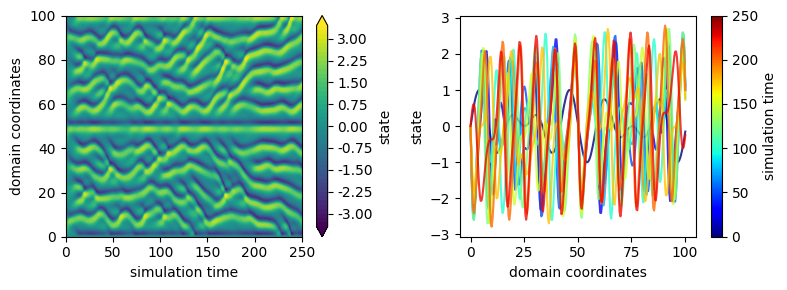

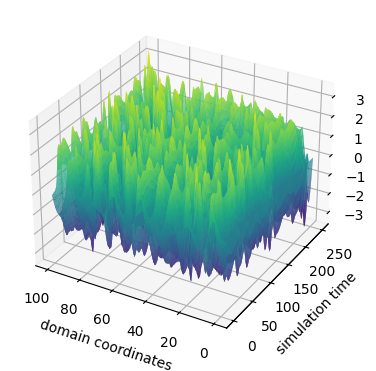

[traj=0 | mode=random] X shape = (256, 501), T = 500


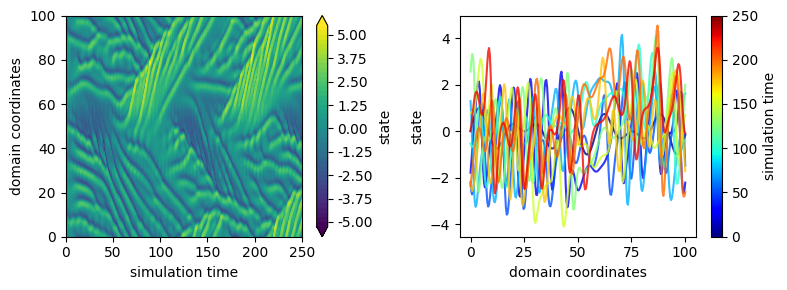

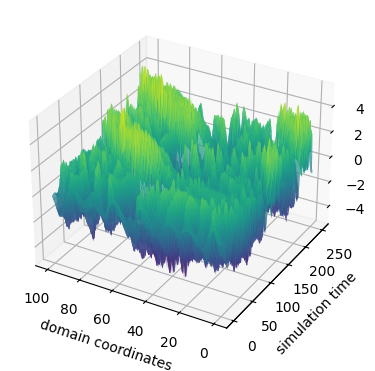

In [8]:
contour = True
surface3d = True
dpi = 300

traj_idx = min(1, data["X"][data["dataset_modes"][0]].shape[0] - 1)
for mode in data["dataset_modes"]:
    _plot_single_from_data(data, traj_idx=traj_idx, mode=mode, contour=contour, surface3d=surface3d, dpi=dpi)


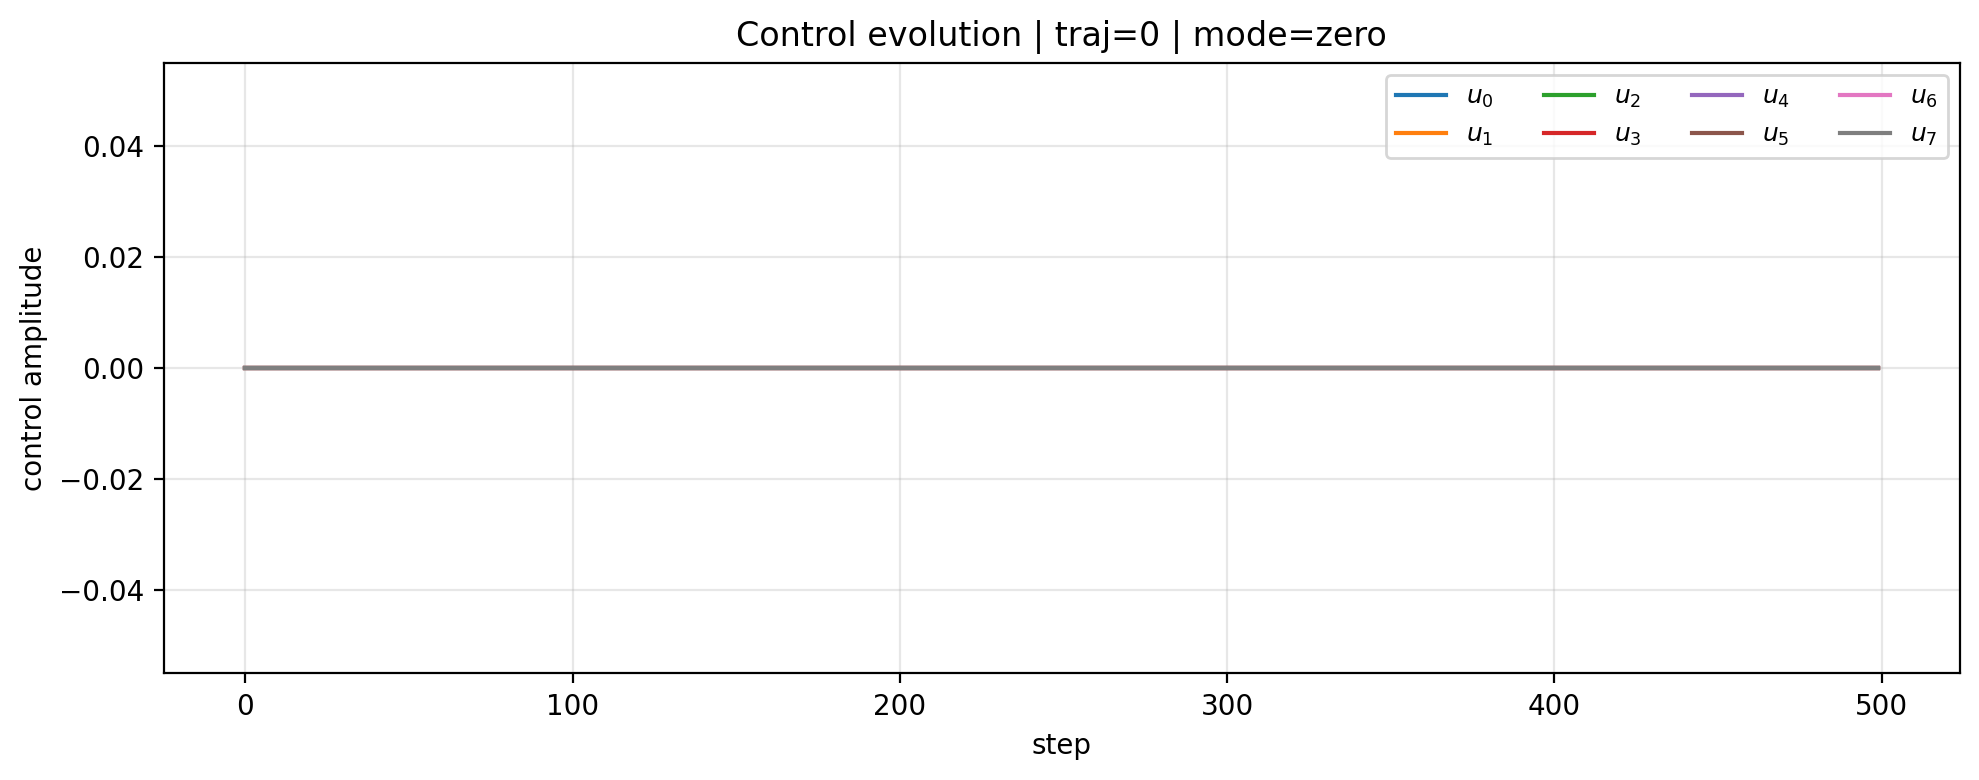

[traj=0 | mode=zero] U shape = (8, 500), T = 500


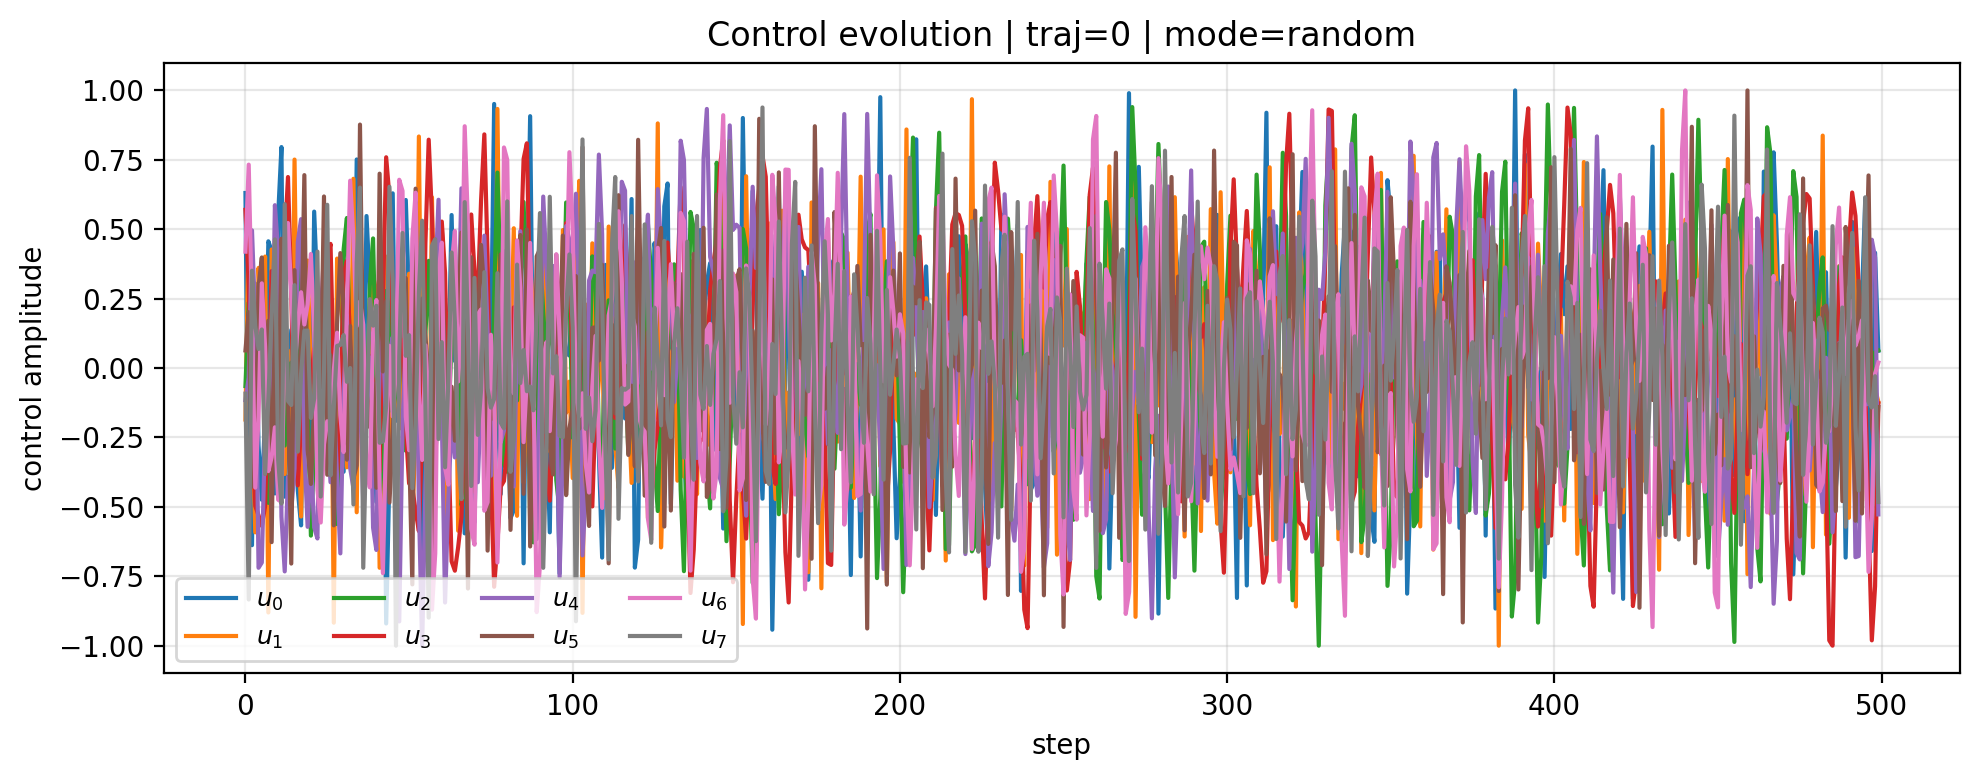

[traj=0 | mode=random] U shape = (8, 500), T = 500


In [9]:
traj_idx = 0
for mode in data["dataset_modes"]:
    _plot_controls_from_data(data, traj_idx=traj_idx, mode=mode, dpi=200)


In [5]:
def build_export_dataset(data, mode="zero", fill_nan=False):
    """
    mode: "zero", "random", or "ctrl"
    Returns:
      solutions:      (N, n_steps+1, n_state)
      init_states:    (N, 1,         n_state)
      controls:       (N, n_steps,   n_action)
      controls_field: (N, n_steps,   n_state)
      R:              (N,)
      T:              (N,)
    """
    if mode not in data["dataset_modes"]:
        raise ValueError(f"mode must be one of {data['dataset_modes']}.")

    X = data["X"][mode]
    U = data["U"][mode]
    F = data["U_field"][mode]

    ds = {
        "solutions": np.transpose(X, (0, 2, 1)),
        "init_states": data["init_states"][:, None, :].copy(),
        "controls": np.transpose(U, (0, 2, 1)),
        "controls_field": np.transpose(F, (0, 2, 1)),
        "R": data["R"][mode].copy(),
        "T": data["T"][mode].copy(),
        "env_id": data.get("env_id"),
        "ctrl_mode": data.get("ctrl_mode"),
        "env_kwargs": dict(data.get("env_kwargs", {})),
        "random_signal_kwargs": dict(data.get("random_signal_kwargs", {})),
        "export_mode": mode,
    }

    if fill_nan:
        for key in ("solutions", "controls", "controls_field"):
            ds[key] = np.nan_to_num(ds[key])

    return ds


In [11]:
for mode in data["dataset_modes"]:
    ds = build_export_dataset(data, mode=mode)
    print(f"{mode}:")
    print(ds["solutions"].shape)
    print(ds["init_states"].shape)
    print(ds["controls"].shape)
    print(ds["controls_field"].shape)
    print(ds["R"].shape, ds["T"].shape)


zero:
(1, 501, 256)
(1, 1, 256)
(1, 500, 8)
(1, 500, 256)
(1,) (1,)
random:
(1, 501, 256)
(1, 1, 256)
(1, 500, 8)
(1, 500, 256)
(1,) (1,)


In [6]:
def check_dataset_diversity(data, dec=10):
    N = data["init_states"].shape[0]
    modes = tuple(data["dataset_modes"])

    same_init_by_mode = {
        mode: np.allclose(data["init_states"], data["X"][mode][:, :, 0])
        for mode in modes
    }

    uniq_init = np.unique(np.round(data["init_states"], dec), axis=0).shape[0]

    unique_rollouts = {}
    for mode in modes:
        signatures = []
        for k in range(N):
            T = int(data["T"][mode][k])
            Xk = np.round(data["X"][mode][k, :, : T + 1], dec)
            Uk = np.round(data["U"][mode][k, :, : T], dec)
            signatures.append((Xk.tobytes(), Uk.tobytes()))
        unique_rollouts[mode] = len(set(signatures))

    print(f"N trajectories: {N}")
    for mode in modes:
        print(f"init_states == X[{mode}][:,:,0]: {same_init_by_mode[mode]}")
    print(f"unique initial states: {uniq_init}/{N}")
    for mode in modes:
        print(f"unique {mode} rollouts: {unique_rollouts[mode]}/{N}")


check_dataset_diversity(data)


NameError: name 'data' is not defined

In [10]:
num_traj = 1000
fullenv_id = preview_env_id
full_dataset_modes = ("zero", "random")

random_signal_kwargs = {
    "signal_mode": "manual",
    "freq_range": (1, 3),
    "min_val": -1,
    "max_val": 1,
    "amp_range": (10, 20),
}
# random_signal_kwargs = {
#     "signal_mode": "env",
#     "cycles_range": (1, 3),
#     "amp_range": (10, 20)
# }
env_kwargs = {
    "n_state": 256,
    "n_observation": 256,
    "n_action": 8,
    "n_steps": 400,
    "process_noise_cov": 0.0,
    "sensor_noise_cov": 1e-8,
    "action_limit": 1.0,
}

data_full = generate_controlled_dataset_nonlinear(
    env_id=fullenv_id,
    n_traj=num_traj,
    dataset_modes=full_dataset_modes,
    random_signal_kwargs=random_signal_kwargs,
    init_seed=123,
    noise_seed=10_000,
    verbose=True,
    **env_kwargs,
)


[1/1000] traj=22.243s | elapsed=22.24s | eta=22220.78s
[2/1000] traj=19.620s | elapsed=41.86s | eta=20889.70s
[3/1000] traj=18.771s | elapsed=60.64s | eta=20150.87s
[4/1000] traj=20.076s | elapsed=80.71s | eta=20096.96s
[5/1000] traj=23.919s | elapsed=104.63s | eta=20821.39s
[6/1000] traj=20.467s | elapsed=125.10s | eta=20724.42s
[7/1000] traj=18.355s | elapsed=143.45s | eta=20349.70s
[8/1000] traj=22.741s | elapsed=166.19s | eta=20607.89s
[9/1000] traj=18.826s | elapsed=185.02s | eta=20372.62s
[10/1000] traj=19.020s | elapsed=204.04s | eta=20199.79s
[11/1000] traj=20.810s | elapsed=224.85s | eta=20215.89s
[12/1000] traj=19.023s | elapsed=243.87s | eta=20078.74s
[13/1000] traj=18.504s | elapsed=262.38s | eta=19920.38s
[14/1000] traj=18.652s | elapsed=281.03s | eta=19792.41s
[15/1000] traj=19.677s | elapsed=300.71s | eta=19746.34s
[16/1000] traj=18.899s | elapsed=319.61s | eta=19655.66s
[17/1000] traj=18.876s | elapsed=338.48s | eta=19572.10s
[18/1000] traj=18.400s | elapsed=356.88s | e

In [11]:
ds = build_export_dataset(data_full, mode="zero")

np.savez_compressed(
    f"{data_full['env_id']}_dataset_zero_{num_traj}.npz",
    solutions=ds["solutions"],
    controls=ds["controls"],
    controls_field=ds["controls_field"],
    R=ds["R"],
    T=ds["T"],
    env_id=np.array(ds["env_id"]),
    ctrl_mode=np.array(ds["ctrl_mode"]),
    export_mode=np.array(ds["export_mode"]),
    env_kwargs_json=np.array(json.dumps(ds["env_kwargs"])),
    random_signal_kwargs_json=np.array(json.dumps(ds["random_signal_kwargs"])),
)


In [12]:
ds = build_export_dataset(data_full, mode="random")

np.savez_compressed(
    f"{data_full['env_id']}_dataset_random_{num_traj}.npz",
    solutions=ds["solutions"],
    controls=ds["controls"],
    controls_field=ds["controls_field"],
    R=ds["R"],
    T=ds["T"],
    env_id=np.array(ds["env_id"]),
    ctrl_mode=np.array(ds["ctrl_mode"]),
    export_mode=np.array(ds["export_mode"]),
    env_kwargs_json=np.array(json.dumps(ds["env_kwargs"])),
    random_signal_kwargs_json=np.array(json.dumps(ds["random_signal_kwargs"])),
)


In [ ]:
# Optional: choose torch device once for PPO examples
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


In [ ]:
# Optional PPO configuration for ctrl mode.
# Keep this lightweight for previews; increase later for real training.
ppo_train_kwargs = {
    "actor_hidden_dim": 64,
    "critic_hidden_dim": 64,
    "lr": 1e-4,
    "discount_factor": 0.99,
    "device": device,
    "num_train_iter": 5,
    "num_episodes_per_iter": 8,
    "episode_length": 100,
    "sgd_epoch_num": 2,
    "mini_batch_size": 8,
    "clip": 0.2,
    "cov_param": 0.05,
}


In [ ]:
# Optional PPO preview. This is intentionally off by default because PPO is slow.
RUN_CTRL_PREVIEW = False
TRAIN_CTRL_IN_NOTEBOOK = False
provided_ppo_controller = None

if RUN_CTRL_PREVIEW:
    data_ctrl = generate_controlled_dataset_nonlinear(
        env_id=preview_env_id,
        n_traj=preview_n_traj,
        dataset_modes=("zero", "random", "ctrl"),
        controller=provided_ppo_controller,
        ctrl_mode="ppo",
        train_controller=TRAIN_CTRL_IN_NOTEBOOK,
        ppo_train_kwargs=ppo_train_kwargs,
        random_signal_kwargs=preview_random_signal_kwargs,
        init_seed=123,
        noise_seed=10_000,
        verbose=True,
        **preview_env_kwargs,
    )
    print("Enabled modes:", data_ctrl["dataset_modes"])
    check_dataset_diversity(data_ctrl)
else:
    print(
        "Skipping optional PPO preview. Set RUN_CTRL_PREVIEW=True and either provide "
        "provided_ppo_controller or set TRAIN_CTRL_IN_NOTEBOOK=True."
    )


In [ ]:
# Optional full data generation with PPO ctrl. This is also off by default.
RUN_CTRL_FULL = False
TRAIN_CTRL_FULL_IN_NOTEBOOK = False
provided_ppo_controller_full = None
num_traj_ctrl = 500

if RUN_CTRL_FULL:
    data_ctrl_full = generate_controlled_dataset_nonlinear(
        env_id=full_env_id,
        n_traj=num_traj_ctrl,
        dataset_modes=("zero", "random", "ctrl"),
        controller=provided_ppo_controller_full,
        ctrl_mode="ppo",
        train_controller=TRAIN_CTRL_FULL_IN_NOTEBOOK,
        ppo_train_kwargs=ppo_train_kwargs,
        random_signal_kwargs=preview_random_signal_kwargs,
        init_seed=123,
        noise_seed=10_000,
        verbose=True,
        **preview_env_kwargs,
    )
else:
    print(
        "Skipping optional PPO full generation. Set RUN_CTRL_FULL=True and either provide "
        "provided_ppo_controller_full or set TRAIN_CTRL_FULL_IN_NOTEBOOK=True."
    )


In [ ]:
# Optional export for the full PPO-enabled dataset.
if RUN_CTRL_FULL and "data_ctrl_full" in globals():
    for mode in data_ctrl_full["dataset_modes"]:
        ds = build_export_dataset(data_ctrl_full, mode=mode)
        np.savez_compressed(
            f"{data_ctrl_full['env_id']}_dataset_{mode}_{num_traj_ctrl}.npz",
            solutions=ds["solutions"],
            controls=ds["controls"],
            controls_field=ds["controls_field"],
            R=ds["R"],
            T=ds["T"],
            env_id=np.array(ds["env_id"]),
            ctrl_mode=np.array(ds["ctrl_mode"]),
            export_mode=np.array(ds["export_mode"]),
            env_kwargs_json=np.array(json.dumps(ds["env_kwargs"])),
            random_signal_kwargs_json=np.array(json.dumps(ds["random_signal_kwargs"])),
        )
        print(f"Saved {mode} dataset for PPO-enabled run.")
else:
    print("No PPO-enabled full dataset to export.")
